# Clohessy–Wiltshire equations: analytical vs. numerical comparison

In this notebook we compare the closed-form analytical solution (State Transition Matrix, STM) with the numerical integration of the Hill equations, using the functions from the `ios_mission_planner` package, and explore several sets of initial conditions to build intuition for what they represent physically.

The Hill equations describe the linearized relative motion of a deputy with respect to a chief on a circular orbit, valid when the relative separation is small compared to the orbital radius:

$$
\ddot{x} - 2n\dot{y} - 3n^2x = 0 \qquad
\ddot{y} + 2n\dot{x} = 0 \qquad
\ddot{z} + n^2z = 0
$$

where $n$ is the mean motion of the chief and $(x,y,z)$ is the relative position of the deputy in the chief's LVLH frame ($x$ radial, $y$ along-track, $z$ cross-track).

Being a linear system with constant coefficients, it admits a closed-form solution (the **Clohessy–Wiltshire solution**) via the State Transition Matrix:

$$
\mathbf{X}(t) = \mathbf{\Phi}(t,t_0)\,\mathbf{X}(t_0), \qquad
\mathbf{X} = \begin{bmatrix} x & y & z & \dot{x} & \dot{y} & \dot{z} \end{bmatrix}^T


In [1]:
from ios_mission_planner.dynamics.relative.hill import hill_equations
from ios_mission_planner.dynamics.relative.cw import cw_state_transition_matrix
from ios_mission_planner.propagation.propagator import propagate

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.grid": True, "grid.alpha": 0.3, "axes.axisbelow": True,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
})

COL_ANA = "#1f77b4"   # analytical solution (CW)
COL_NUM = "#d62728"   # numerical integration (Hill)
COL_CHIEF = "#2ca02c"


In [2]:
# Chief parameters: reference circular LEO orbit
mu_earth = 398600.4418  # km^3/s^2
alt = 500.0              # km
a = 6378.137 + alt       # km, orbital radius (circular orbit)
n = np.sqrt(mu_earth / a**3)  # rad/s, mean motion
T = 2 * np.pi / n             # s, orbital period

print(f"n = {n:.6e} rad/s")
print(f"T = {T:.1f} s  ({T/60:.2f} min)")

n = 1.106783e-03 rad/s
T = 5677.0 s  (94.62 min)


## Wrapper functions around the package

`cw_state_transition_matrix(t, n)` needs to be evaluated at each time step and multiplied by the initial state to get the analytical propagation. `propagate(...)` is the generic propagator: we pass it `hill_equations` as the dynamics and `n` as an extra parameter (forwarded to `hill_equations` via `**kwargs`).

`propagate` now also accepts `method`, `rtol`, and `atol` as explicit keyword arguments (defaulting to `solve_ivp`'s own defaults, so existing calls are unaffected). Here we use `method="DOP853"` with `rtol=atol=1e-12` for a high-accuracy integration, so the numerical solution agrees with the analytical STM down to essentially machine precision.

In [3]:
def propagate_analytical(state0, t_eval, n):
    """Propagation using the CW state transition matrix, evaluated at each time step."""
    return np.array([cw_state_transition_matrix(t, n) @ state0 for t in t_eval])


def propagate_numerical(state0, t_eval, n):
    """Numerical propagation of the Hill equations, at high accuracy."""
    solution = propagate(hill_equations, state0, (t_eval[0], t_eval[-1]), t_eval,
                          method="DOP853", rtol=1e-12, atol=1e-12, n=n)
    return solution.y.T

## Plotting function

For each case we show: the 3D trajectory in the LVLH frame, the projection onto the orbital plane (x-y), the position and velocity components over time, and the position error between the analytical and numerical solutions (to check consistency between the two methods).

In [4]:
def run_case(state0, n_periods, n_pts=800):
    t_eval = np.linspace(0, n_periods * T, n_pts)
    ana = propagate_analytical(state0, t_eval, n)
    num = propagate_numerical(state0, t_eval, n)
    err = np.linalg.norm(ana[:, :3] - num[:, :3], axis=1)
    return t_eval, ana, num, err


def plot_case(title, t_eval, ana, num, err, elev=25, azim=-50):
    t_p = t_eval / T
    x_a, y_a, z_a = ana[:, 0], ana[:, 1], ana[:, 2]
    x_n, y_n, z_n = num[:, 0], num[:, 1], num[:, 2]

    fig = plt.figure(figsize=(11, 8))
    fig.suptitle(title, fontsize=13, fontweight="bold", y=0.99)
    gs = fig.add_gridspec(2, 3, height_ratios=[1.3, 1], hspace=0.4, wspace=0.32, top=0.90)

    ax3d = fig.add_subplot(gs[0, :2], projection="3d")
    ax3d.plot(x_a, y_a, z_a, color=COL_ANA, lw=2, label="CW analytical (STM)")
    ax3d.plot(x_n, y_n, z_n, color=COL_NUM, lw=1.2, ls="--", label="Numerical (Hill ODE)")
    ax3d.scatter([0], [0], [0], color=COL_CHIEF, s=60, marker="^", label="Chief", depthshade=False)
    ax3d.scatter([x_a[0]], [y_a[0]], [z_a[0]], color="k", s=35, marker="o", label="Deputy $t_0$", depthshade=False)
    ax3d.set_xlabel("x — radial [m]"); ax3d.set_ylabel("y — along-track [m]"); ax3d.set_zlabel("z — cross-track [m]")
    ax3d.set_title("3D relative trajectory (LVLH)", fontsize=10)
    ax3d.legend(loc="upper right", bbox_to_anchor=(1.32, 1.0), fontsize=8, framealpha=0.9)
    ax3d.view_init(elev=elev, azim=azim)

    ax_xy = fig.add_subplot(gs[0, 2])
    ax_xy.plot(y_a, x_a, color=COL_ANA, lw=2)
    ax_xy.plot(y_n, x_n, color=COL_NUM, lw=1.2, ls="--")
    ax_xy.scatter([0], [0], color=COL_CHIEF, s=60, marker="^", zorder=5)
    ax_xy.scatter([y_a[0]], [x_a[0]], color="k", s=30, zorder=5)
    ax_xy.set_xlabel("y — along-track [m]"); ax_xy.set_ylabel("x — radial [m]")
    ax_xy.set_title("In-plane projection", fontsize=10)
    ax_xy.set_aspect("equal", adjustable="datalim")

    ax_pos = fig.add_subplot(gs[1, 0])
    for lbl, a_, n_, c in zip(["x", "y", "z"], [x_a, y_a, z_a], [x_n, y_n, z_n],
                               ["#1f77b4", "#ff7f0e", "#2ca02c"]):
        ax_pos.plot(t_p, a_, color=c, lw=1.6, label=lbl)
        ax_pos.plot(t_p, n_, color=c, lw=1, ls="--")
    ax_pos.set_xlabel("time [orbital periods]"); ax_pos.set_ylabel("position [m]")
    ax_pos.set_title("Position vs. time"); ax_pos.legend(fontsize=8, ncol=3)

    ax_vel = fig.add_subplot(gs[1, 1])
    for lbl, a_, n_, c in zip(["vx", "vy", "vz"], [ana[:, 3], ana[:, 4], ana[:, 5]],
                               [num[:, 3], num[:, 4], num[:, 5]], ["#1f77b4", "#ff7f0e", "#2ca02c"]):
        ax_vel.plot(t_p, a_, color=c, lw=1.6, label=lbl)
        ax_vel.plot(t_p, n_, color=c, lw=1, ls="--")
    ax_vel.set_xlabel("time [orbital periods]"); ax_vel.set_ylabel("velocity [m/s]")
    ax_vel.set_title("Velocity vs. time"); ax_vel.legend(fontsize=8, ncol=3)

    ax_err = fig.add_subplot(gs[1, 2])
    ax_err.semilogy(t_p, np.clip(err, 1e-14, None), color="k", lw=1.4)
    ax_err.set_xlabel("time [orbital periods]"); ax_err.set_ylabel("|position error| [m]")
    ax_err.set_title("Analytical vs. numerical", fontsize=10)

    plt.show()
    print(f"max position error: {err.max():.3e} m")

## Case studies

Each case is defined by an initial state $\mathbf{X}_0 = [x_0, y_0, z_0, \dot x_0, \dot y_0, \dot z_0]^T$ in the chief's LVLH frame. Together they illustrate the qualitative behavior of the CW equations, from cases relevant to proximity operations (RPO/IOS) to the secular behavior of the relative motion.

### Case A: periodic, drift-free ellipse

A purely radial offset $x_0 = 50$ m with an initial along-track velocity satisfying the drift-free condition:

$$\dot y_0 = -2n x_0$$

The result is the classic **2:1 ellipse** (along-track semi-axis = 2× the radial one), centered on the chief and repeating exactly every orbital period, the "natural" reference relative trajectory used in many proximity-operations maneuvers.

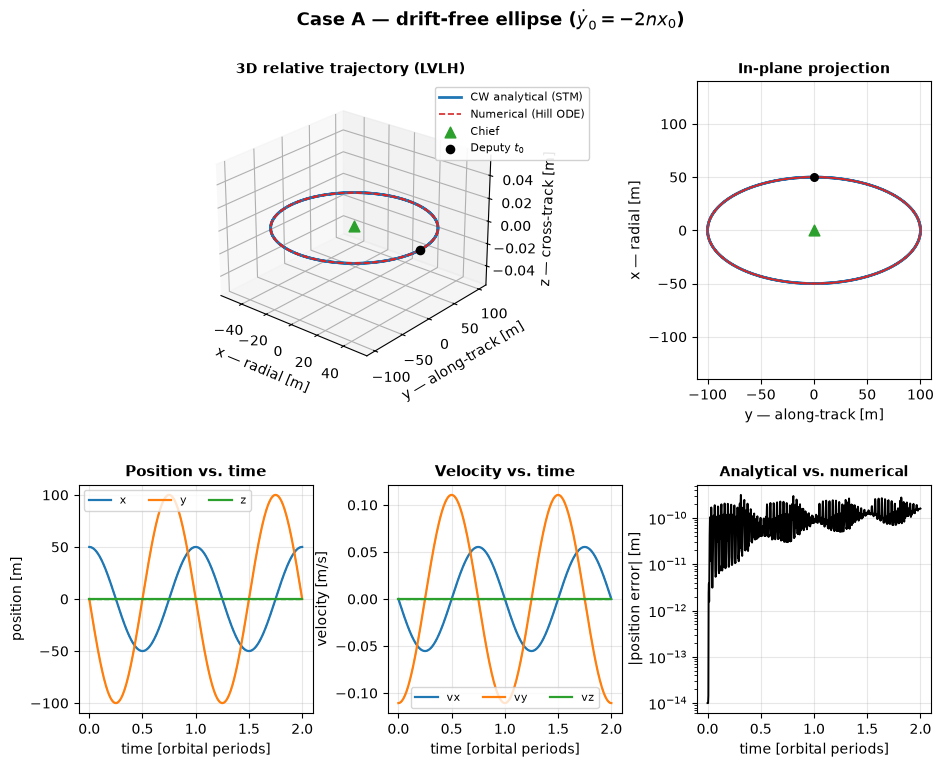

max position error: 3.151e-10 m


In [5]:
x0 = 50.0
state0_A = [x0, 0.0, 0.0, 0.0, -2*n*x0, 0.0]

t_eval, ana, num, err = run_case(state0_A, n_periods=2)
plot_case("Case A — drift-free ellipse ($\\dot y_0=-2nx_0$)", t_eval, ana, num, err)

### Case B: same radial offset, zero relative velocity

Same $x_0 = 50$ m but $\dot{\mathbf X}_0 = 0$: the drift-free condition is not satisfied. The deputy ends up on an orbit with a slightly different semi-major axis than the chief's, hence a different period: the result is a **secular drift along $y$** that grows linearly in time, superimposed on the periodic oscillation. This is why a purely radial offset, unless paired with the right velocity, is never a stable "hold" configuration.

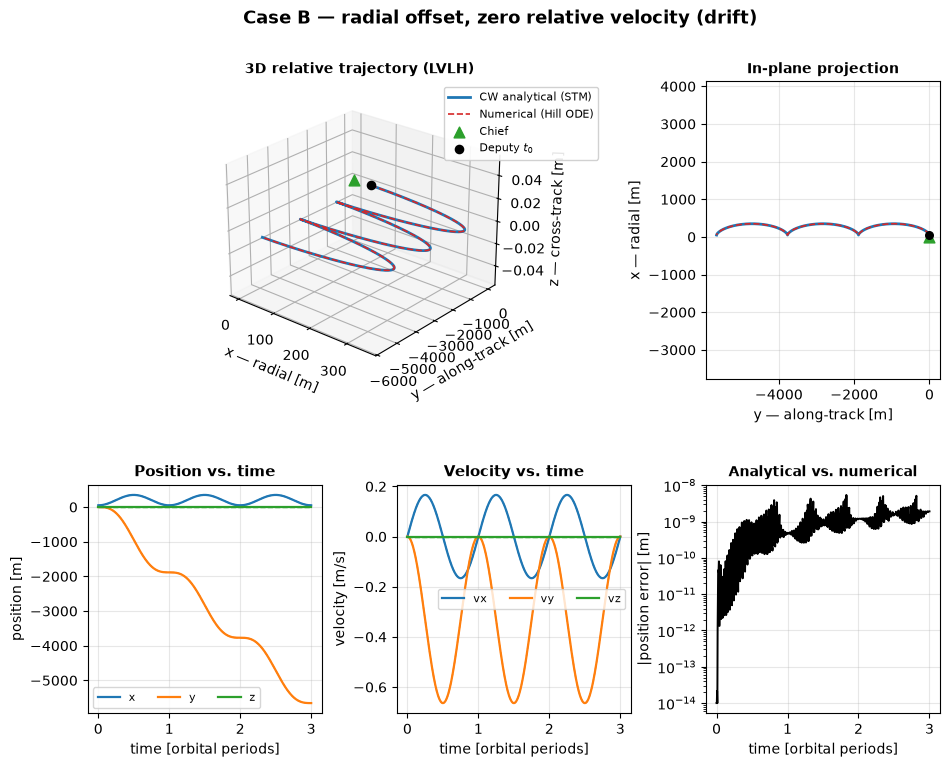

max position error: 5.404e-09 m


In [6]:
state0_B = [x0, 0.0, 0.0, 0.0, 0.0, 0.0]

t_eval, ana, num, err = run_case(state0_B, n_periods=3)
plot_case("Case B — radial offset, zero relative velocity (drift)", t_eval, ana, num, err)

### Case C: V-bar hold point

A purely along-track offset $y_0 = 80$ m, $x_0=0$, zero relative velocity. Unlike Case B, this is a **stable equilibrium** configuration: chief and deputy share the same semi-major axis (same orbital energy), so there is no secular drift. This is the ideal case for a hold point along the V-bar during a rendezvous operation.

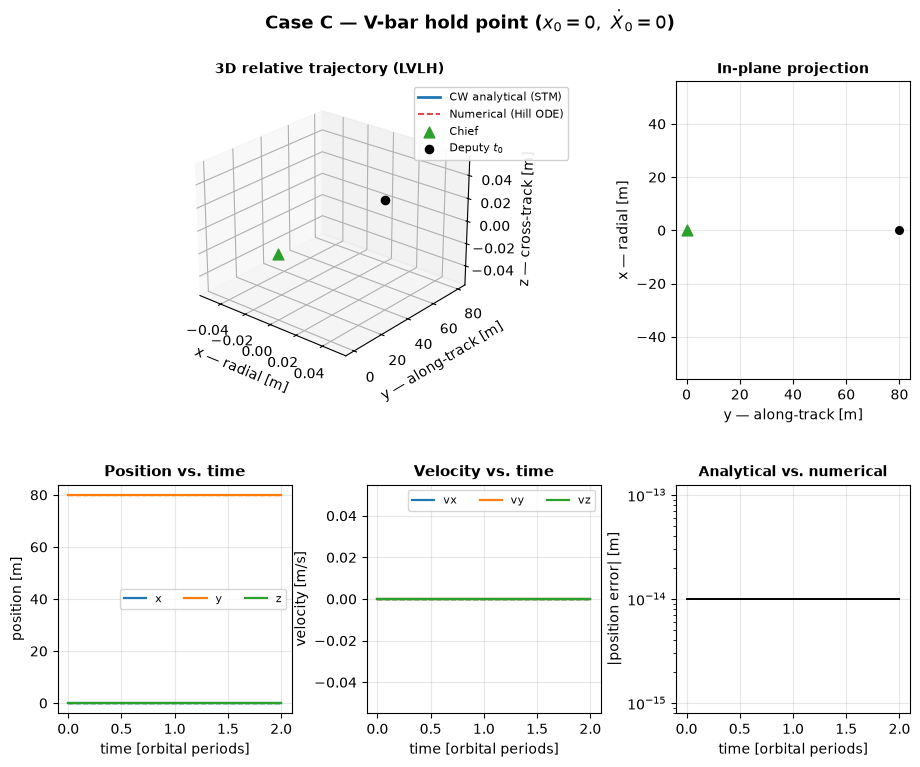

max position error: 0.000e+00 m


In [7]:
y0 = 80.0
state0_C = [0.0, y0, 0.0, 0.0, 0.0, 0.0]

t_eval, ana, num, err = run_case(state0_C, n_periods=2)
plot_case("Case C — V-bar hold point ($x_0=0,\\ \\dot X_0=0$)", t_eval, ana, num, err)

### Case D: Natural Motion Circumnavigation (3D)

Adding an out-of-plane oscillation with the same frequency $n$ and a matching amplitude ($\dot z_0 = n z_0$) to the drift-free ellipse of Case A produces a **tilted 3D ellipse**: the deputy circumnavigates the chief, periodically passing above, below, in front of, and behind it, without ever requiring propulsive corrections (natural motion). This is the basis of the passive inspection trajectories (NMC) used in RPO/IOS missions.

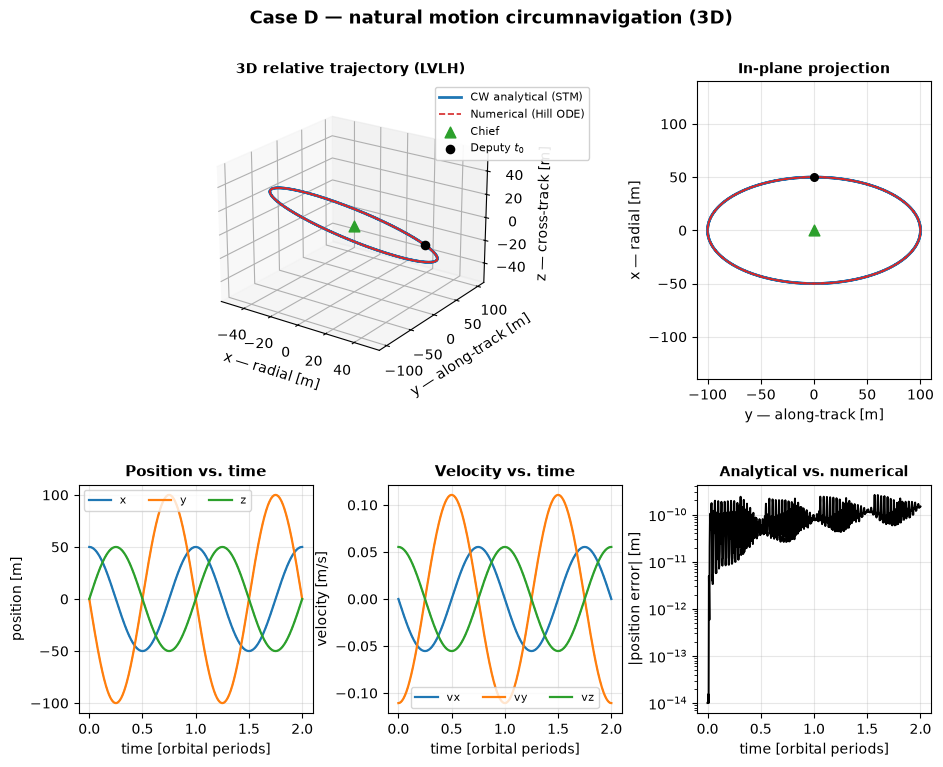

max position error: 2.614e-10 m


In [8]:
z0 = 50.0
zdot0 = z0 * n
state0_D = [x0, 0.0, 0.0, 0.0, -2*n*x0, zdot0]

t_eval, ana, num, err = run_case(state0_D, n_periods=2)
plot_case("Case D — natural motion circumnavigation (3D)", t_eval, ana, num, err, elev=22, azim=-55)

### Case E — general condition over several orbits

A generic, non-drift-free initial state, propagated over 8 orbital periods. Notice the superposition of a periodic oscillation and a growing secular drift in $y$ — the typical behavior of a deputy "left free" with no special initial conditions. With the tight integration tolerances used here, the error between the analytical STM and the numerical integration stays below 1e-8 m even over 8 orbits, confirming that the two approaches describe the same linear dynamics.

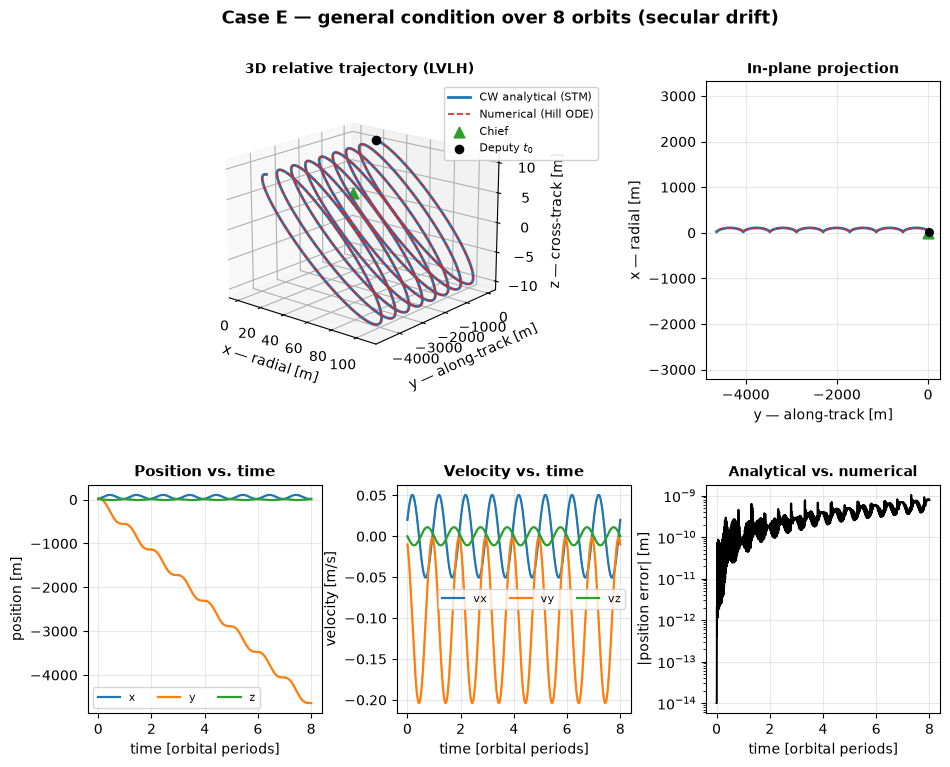

max position error: 1.036e-09 m


In [9]:
state0_E = [20.0, 30.0, 10.0, 0.02, -0.01, 0.0]

t_eval, ana, num, err = run_case(state0_E, n_periods=8, n_pts=2000)
plot_case("Case E — general condition over 8 orbits (secular drift)", t_eval, ana, num, err, elev=18, azim=-50)

## Summary

- **A vs. B**: the condition $\dot y_0 = -2nx_0$ is what distinguishes a periodic relative orbit from a drifting one — it's the best-known drift-free condition in the CW framework.
- **C**: a purely along-track offset is naturally stable — useful for hold/wait points during a rendezvous.
- **D**: combining radial and cross-track offsets with the correct phasing yields natural 3D inspection trajectories (NMC), with no propellant expenditure.
- **E**: without special conditions, the relative motion is the sum of a periodic term and a secular one (linear drift in $y$) — consistent with the structure of the $\Phi$ matrix, where the $(2,1)$ block contains the $6(\sin nt - nt)$ term responsible for the drift.
- With `propagate()` called at `rtol=atol=1e-12` (`method="DOP853"`), the analytical/numerical agreement is at the level of the integrator's own numerical noise (< 1e-8 m) in every case, confirming that the CW closed-form solution is an exact linearization of the Hill equations in this regime.